# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The CSV files are already available in this workspace. Load them from the local folders below.

- patient_demographics/patient_demographics.csv
- clinical_data/clinical_data.csv
- lifestyle_factors/lifestyle_factors.csv

In [2]:
from pathlib import Path

base_dir = Path.cwd()

base_dir

WindowsPath('d:/journey/fusemachines/week1 - datawrangling')

In [3]:
# Load datasets from the local workspace
demographics = pd.read_csv(base_dir / "patient_demographics.csv")
clinical = pd.read_csv(base_dir / "clinical_data.csv")
lifestyle = pd.read_csv(base_dir / "lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [4]:
print("Demographics - first 5 rows:")
display(demographics.head())

print("\nDemographics info:")
demographics.info()

print("\nDemographics summary statistics:")
display(demographics.describe(include='all'))

Demographics - first 5 rows:


,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere



Demographics info:
<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Patient ID  8763 non-null   str  
 1   Age         8763 non-null   int64
 2   Sex         8763 non-null   str  
 3   Income      8763 non-null   int64
 4   Country     8763 non-null   str  
 5   Continent   8763 non-null   str  
 6   Hemisphere  8763 non-null   str  
dtypes: int64(2), str(5)
memory usage: 479.4 KB

Demographics summary statistics:


,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
count,8763,8763.000000,8763,8763.000000,8763,8763,8763
unique,8763,NaN,2,NaN,20,6,2
top,BMW7812,NaN,Male,NaN,Germany,Asia,Northern Hemisphere
freq,1,NaN,6111,NaN,477,2543,5660
mean,NaN,53.707977,NaN,158263.181901,NaN,NaN,NaN
std,NaN,21.249509,NaN,80575.190806,NaN,NaN,NaN
min,NaN,18.000000,NaN,20062.000000,NaN,NaN,NaN
25%,NaN,35.000000,NaN,88310.000000,NaN,NaN,NaN
50%,NaN,54.000000,NaN,157866.000000,NaN,NaN,NaN
75%,NaN,72.000000,NaN,227749.000000,NaN,NaN,NaN


In [5]:
# Inspect the clinical dataset
print("Clinical dataset - first 5 rows:")
display(clinical.head())

print("Clinical dataset info:")
clinical.info()

print("\nClinical dataset summary statistics:")
display(clinical.describe(include='all'))

Clinical dataset - first 5 rows:


,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571
3,JLN3497,383,163/100,73,1,1,378,36.464704
4,GFO8847,318,91/88,93,1,1,231,21.809144


Clinical dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   str    
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   str    
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB

Clinical dataset summary statistics:


,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763,8763.000000,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
unique,8763,NaN,3915,NaN,NaN,NaN,NaN,NaN
top,BMW7812,NaN,146/94,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,8,NaN,NaN,NaN,NaN,NaN
mean,NaN,259.877211,NaN,75.021682,0.652288,0.492982,417.677051,28.891446
std,NaN,80.863276,NaN,20.550948,0.476271,0.499979,223.748137,6.319181
min,NaN,120.000000,NaN,40.000000,0.000000,0.000000,30.000000,18.002337
25%,NaN,192.000000,NaN,57.000000,0.000000,0.000000,225.500000,23.422985
50%,NaN,259.000000,NaN,75.000000,1.000000,0.000000,417.000000,28.768999
75%,NaN,330.000000,NaN,93.000000,1.000000,1.000000,612.000000,34.324594


In [7]:
# Inspect the Lifestyle dataset
print("Lifestyle dataset - first 5 rows:")
display(lifestyle.head())

print("Lifestyle dataset info:")
lifestyle.info()

print("Lifestyle dataset summary statistics:")
display(lifestyle.describe(include='all'))

Lifestyle dataset - first 5 rows:


,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0


Lifestyle dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   str    
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   float64
 5   Diet                     8763 non-null   str    
 6   Stress Level             8763 non-null   int64  
 7   Heart Attack Risk        8763 non-null   int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB
Lifestyle dataset summary statistics:


,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
count,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763,8763.000000,8763.000000
unique,8763,NaN,NaN,NaN,NaN,3,NaN,NaN
top,BMW7812,NaN,NaN,NaN,NaN,Healthy,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,2960,NaN,NaN
mean,NaN,0.896839,0.501426,0.598083,10.014284,NaN,5.469702,0.358211
std,NaN,0.304186,0.500026,0.490313,5.783745,NaN,2.859622,0.479502
min,NaN,0.000000,0.000000,0.000000,0.002442,NaN,1.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,4.981579,NaN,3.000000,0.000000
50%,NaN,1.000000,1.000000,1.000000,10.069559,NaN,5.000000,0.000000
75%,NaN,1.000000,1.000000,1.000000,15.050018,NaN,8.000000,1.000000


# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
#### Qn. Is it stored as a number or string?
- Ans: It was stored as a string (specifically as a "string object" in Pandas). Because it had a slash / inside it (like "158/88"), Pandas could not treat it as a single number.

#### Qn. Can we compute averages directly?
- Ans: No. If we try to run .mean() on the original column, we will get an error or a blank result. We can't calculate a mathematical average on string.


### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [8]:
# Split the Blood Pressure column into Systolic and Diastolic
clinical[['Systolic', 'Diastolic']] = clinical['Blood Pressure'].str.split('/', expand=True)

In [9]:
# Convert the new columns to numeric types to enable calculations
clinical['Systolic'] = pd.to_numeric(clinical['Systolic'])
clinical['Diastolic'] = pd.to_numeric(clinical['Diastolic'])

In [10]:
# View the first few rows to verify
print("New columns added:")
display(clinical.head())

New columns added:


,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic,Diastolic
0,BMW7812,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,318,91/88,93,1,1,231,21.809144,91,88


## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
#### Qn. Which columns have missing values?
- Ans: None. After running the check using full_df.isnull().sum(), we verified that every single column in the combined dataset has 0 missing values.

#### Qn. Why might values be missing?
- Ans:  In a real-world medical setting, values might be missing for several reasons:

Patient Privacy: A patient might refuse to answer personal questions about their Income or Diet.

Human Error: A nurse or doctor might forget to enter a value like Heart Rate into the system during a busy shift.

Equipment Issues: A blood pressure cuff or heart monitor might fail during the exam, leaving that field empty.


### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [13]:
# Check for missing values in all three datasets
print("Missing values in Demographics:")
print(demographics.isnull().sum())

Missing values in Demographics:
Patient ID    0
Age           0
Sex           0
Income        0
Country       0
Continent     0
Hemisphere    0
dtype: int64


In [14]:
print("\nMissing values in Clinical:")
print(clinical.isnull().sum())


Missing values in Clinical:
Patient ID        0
Cholesterol       0
Blood Pressure    0
Heart Rate        0
Diabetes          0
Family History    0
Triglycerides     0
BMI               0
Systolic          0
Diastolic         0
dtype: int64


In [15]:
print("\nMissing values in Lifestyle:")
print(lifestyle.isnull().sum())


Missing values in Lifestyle:
Patient ID                 0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64


# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:

#### Qn. Which variables are normally distributed?

- Ans: Based on the skewness calculations, all numerical variables (including Age, BMI, Cholesterol, Income, and triglycerides) are approximately normally distributed. Their skewness values are all extremely close to 0 (ranging from -0.02 to +0.03).

#### Qn. Which variables are skewed left or right?

- Ans: Among numerical features, none are significantly skewed. All features fall well within the "Approximately Normal" range of -0.5 to 0.5.

#### Qn. Are there any unexpected spikes or gaps?

- Ans: The histograms show a very uniform and smooth distribution for most variables. There were no major gaps, which suggests the data is well-spread across its entire range.

#### Qn. Based on the distribution shape, would any feature likely need a transformation before modeling?

- Ans: No transformations are needed. Since all features have a skewness value near 0, standard transformations like Log, Square Root, or Yeo-Johnson would not significantly improve the distribution. The data is already in an ideal state for models that assume normality.

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


In [189]:
# 1. Merge all three datasets into one 'full_df'
full_df = pd.merge(demographics, clinical, on="Patient ID")
full_df = pd.merge(full_df, lifestyle, on="Patient ID")

continuous_cols = [
    "Age",
    "Income",
    "Cholesterol",
    "Heart Rate",
    "Triglycerides",
    "BMI",
    "Systolic",
    "Diastolic",
    "Exercise Hours Per Week",
]

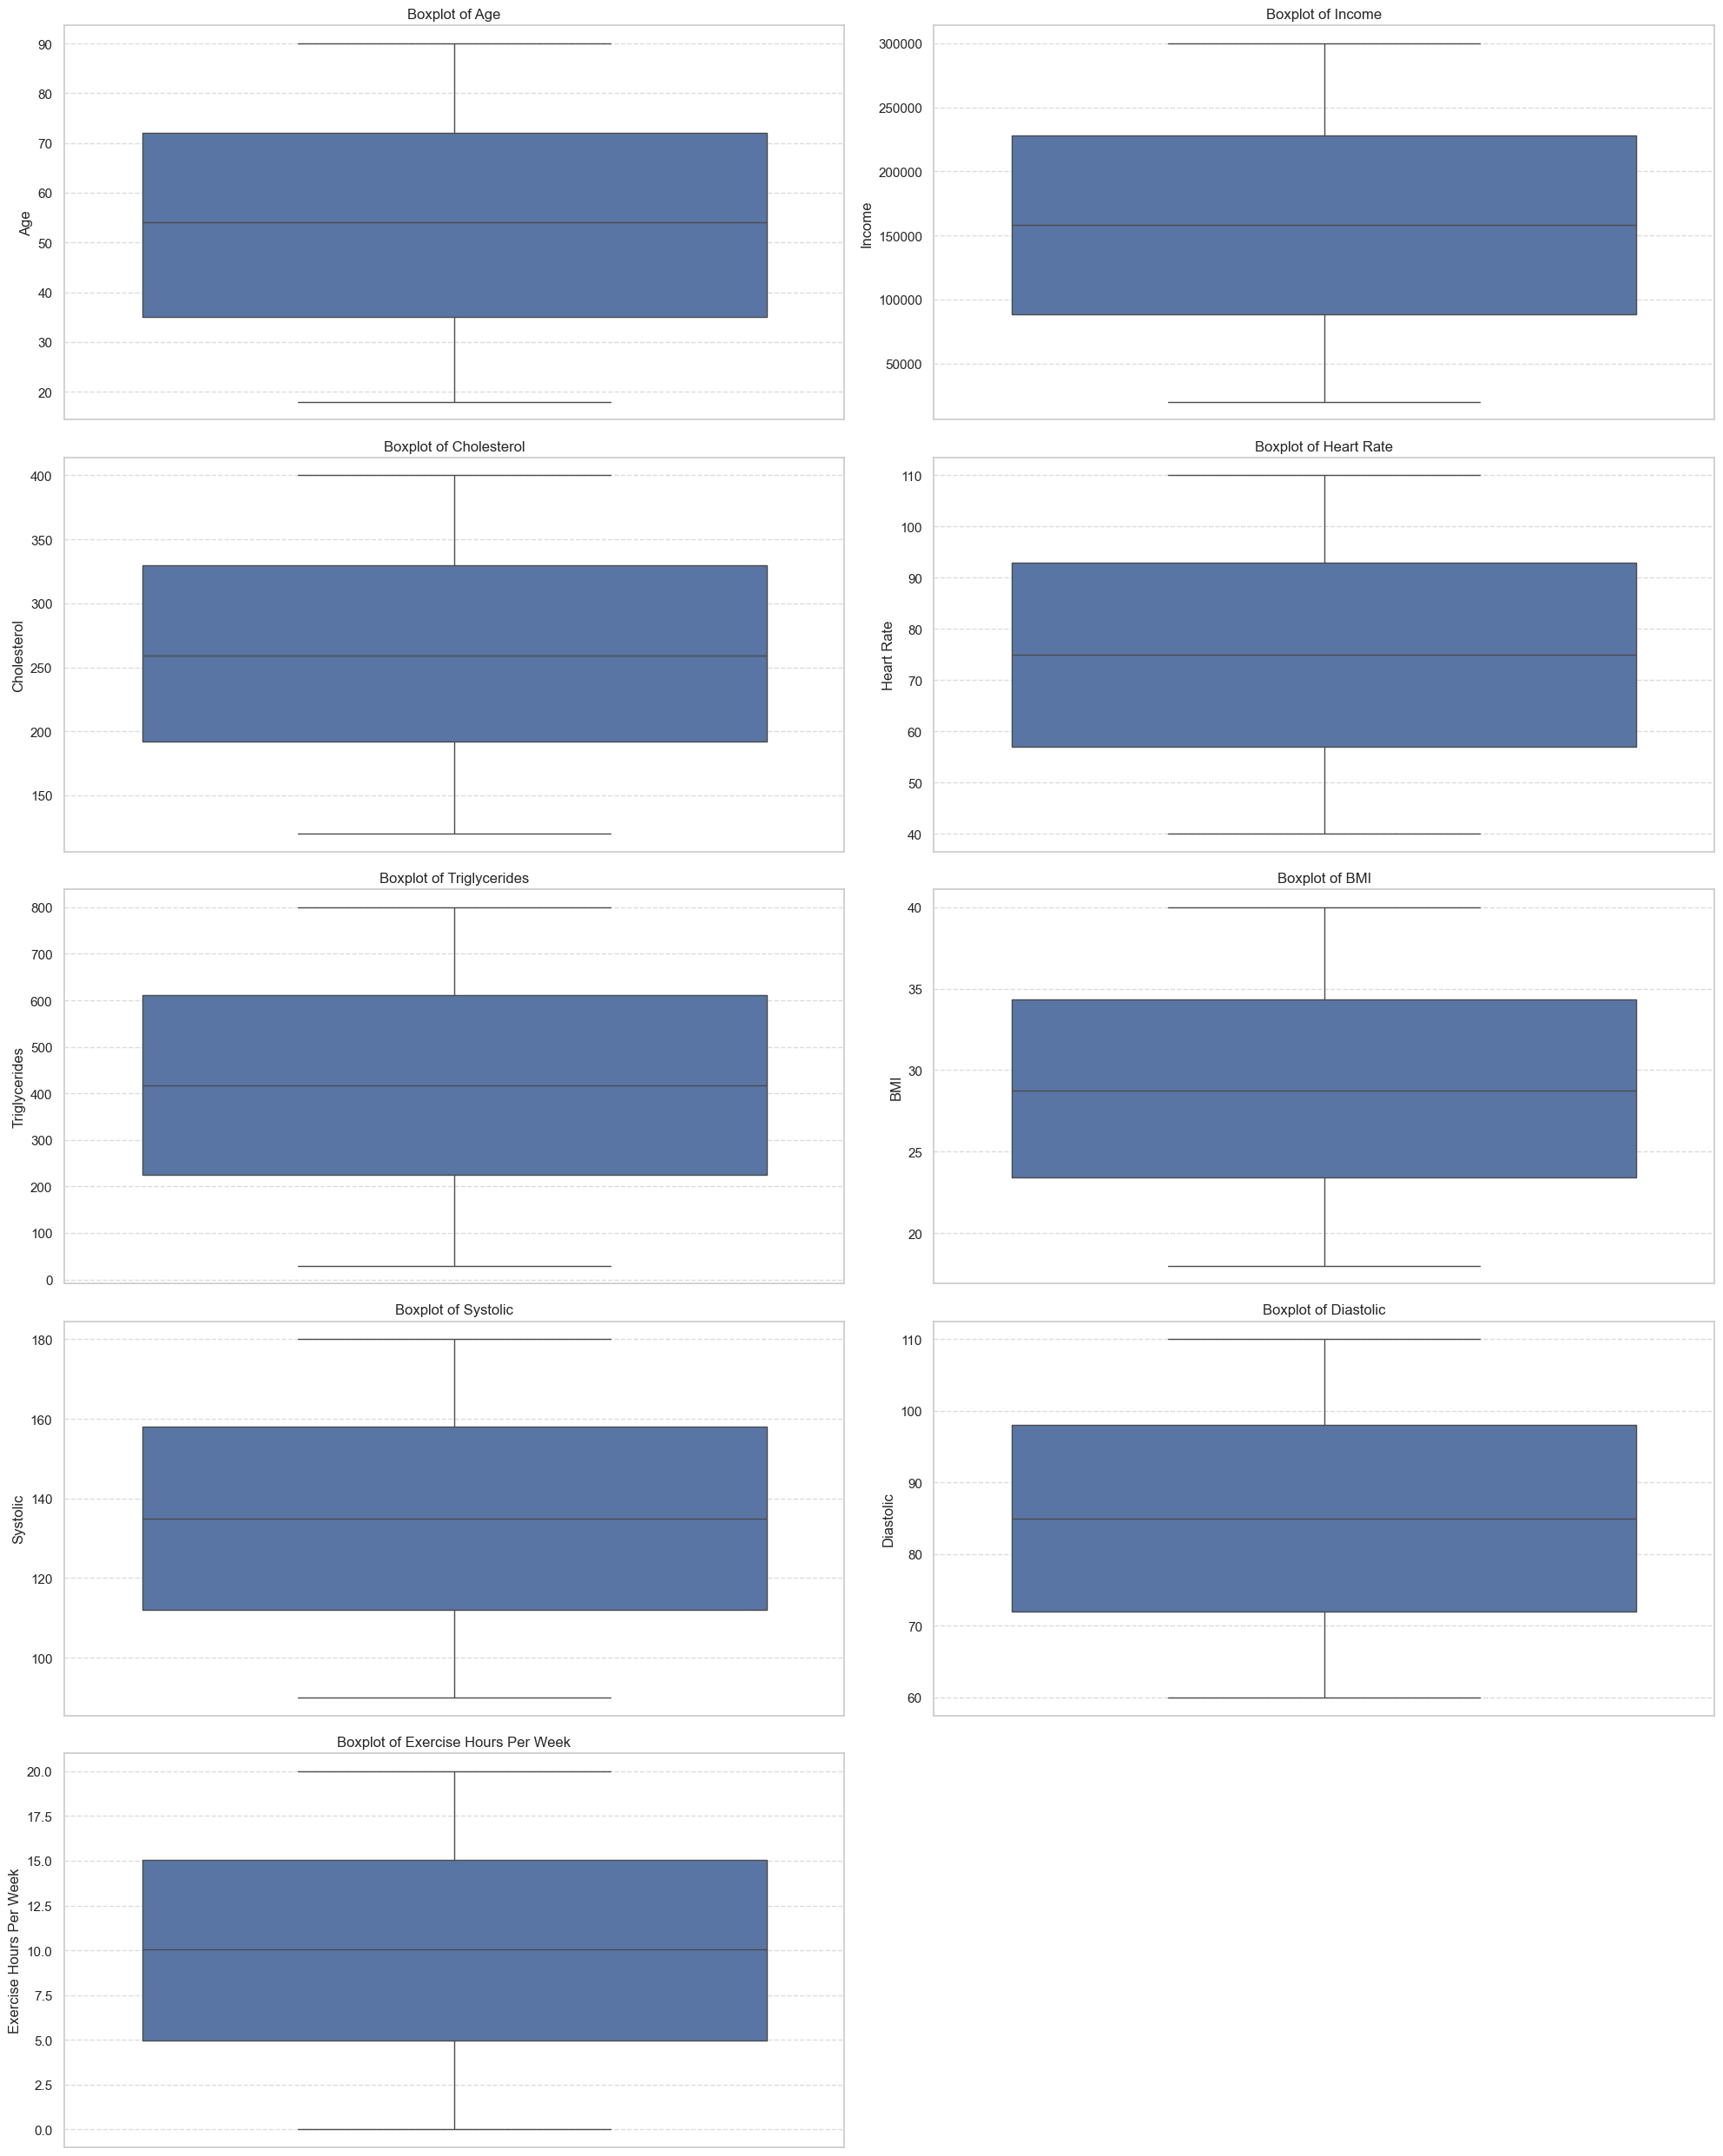

In [195]:
import math

cols = 2
rows = math.ceil(len(continuous_cols) / cols)

plt.figure(figsize=(20, rows * 5))

for i, col in enumerate(continuous_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(data=full_df, y=col)
    plt.title(f'Boxplot of {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

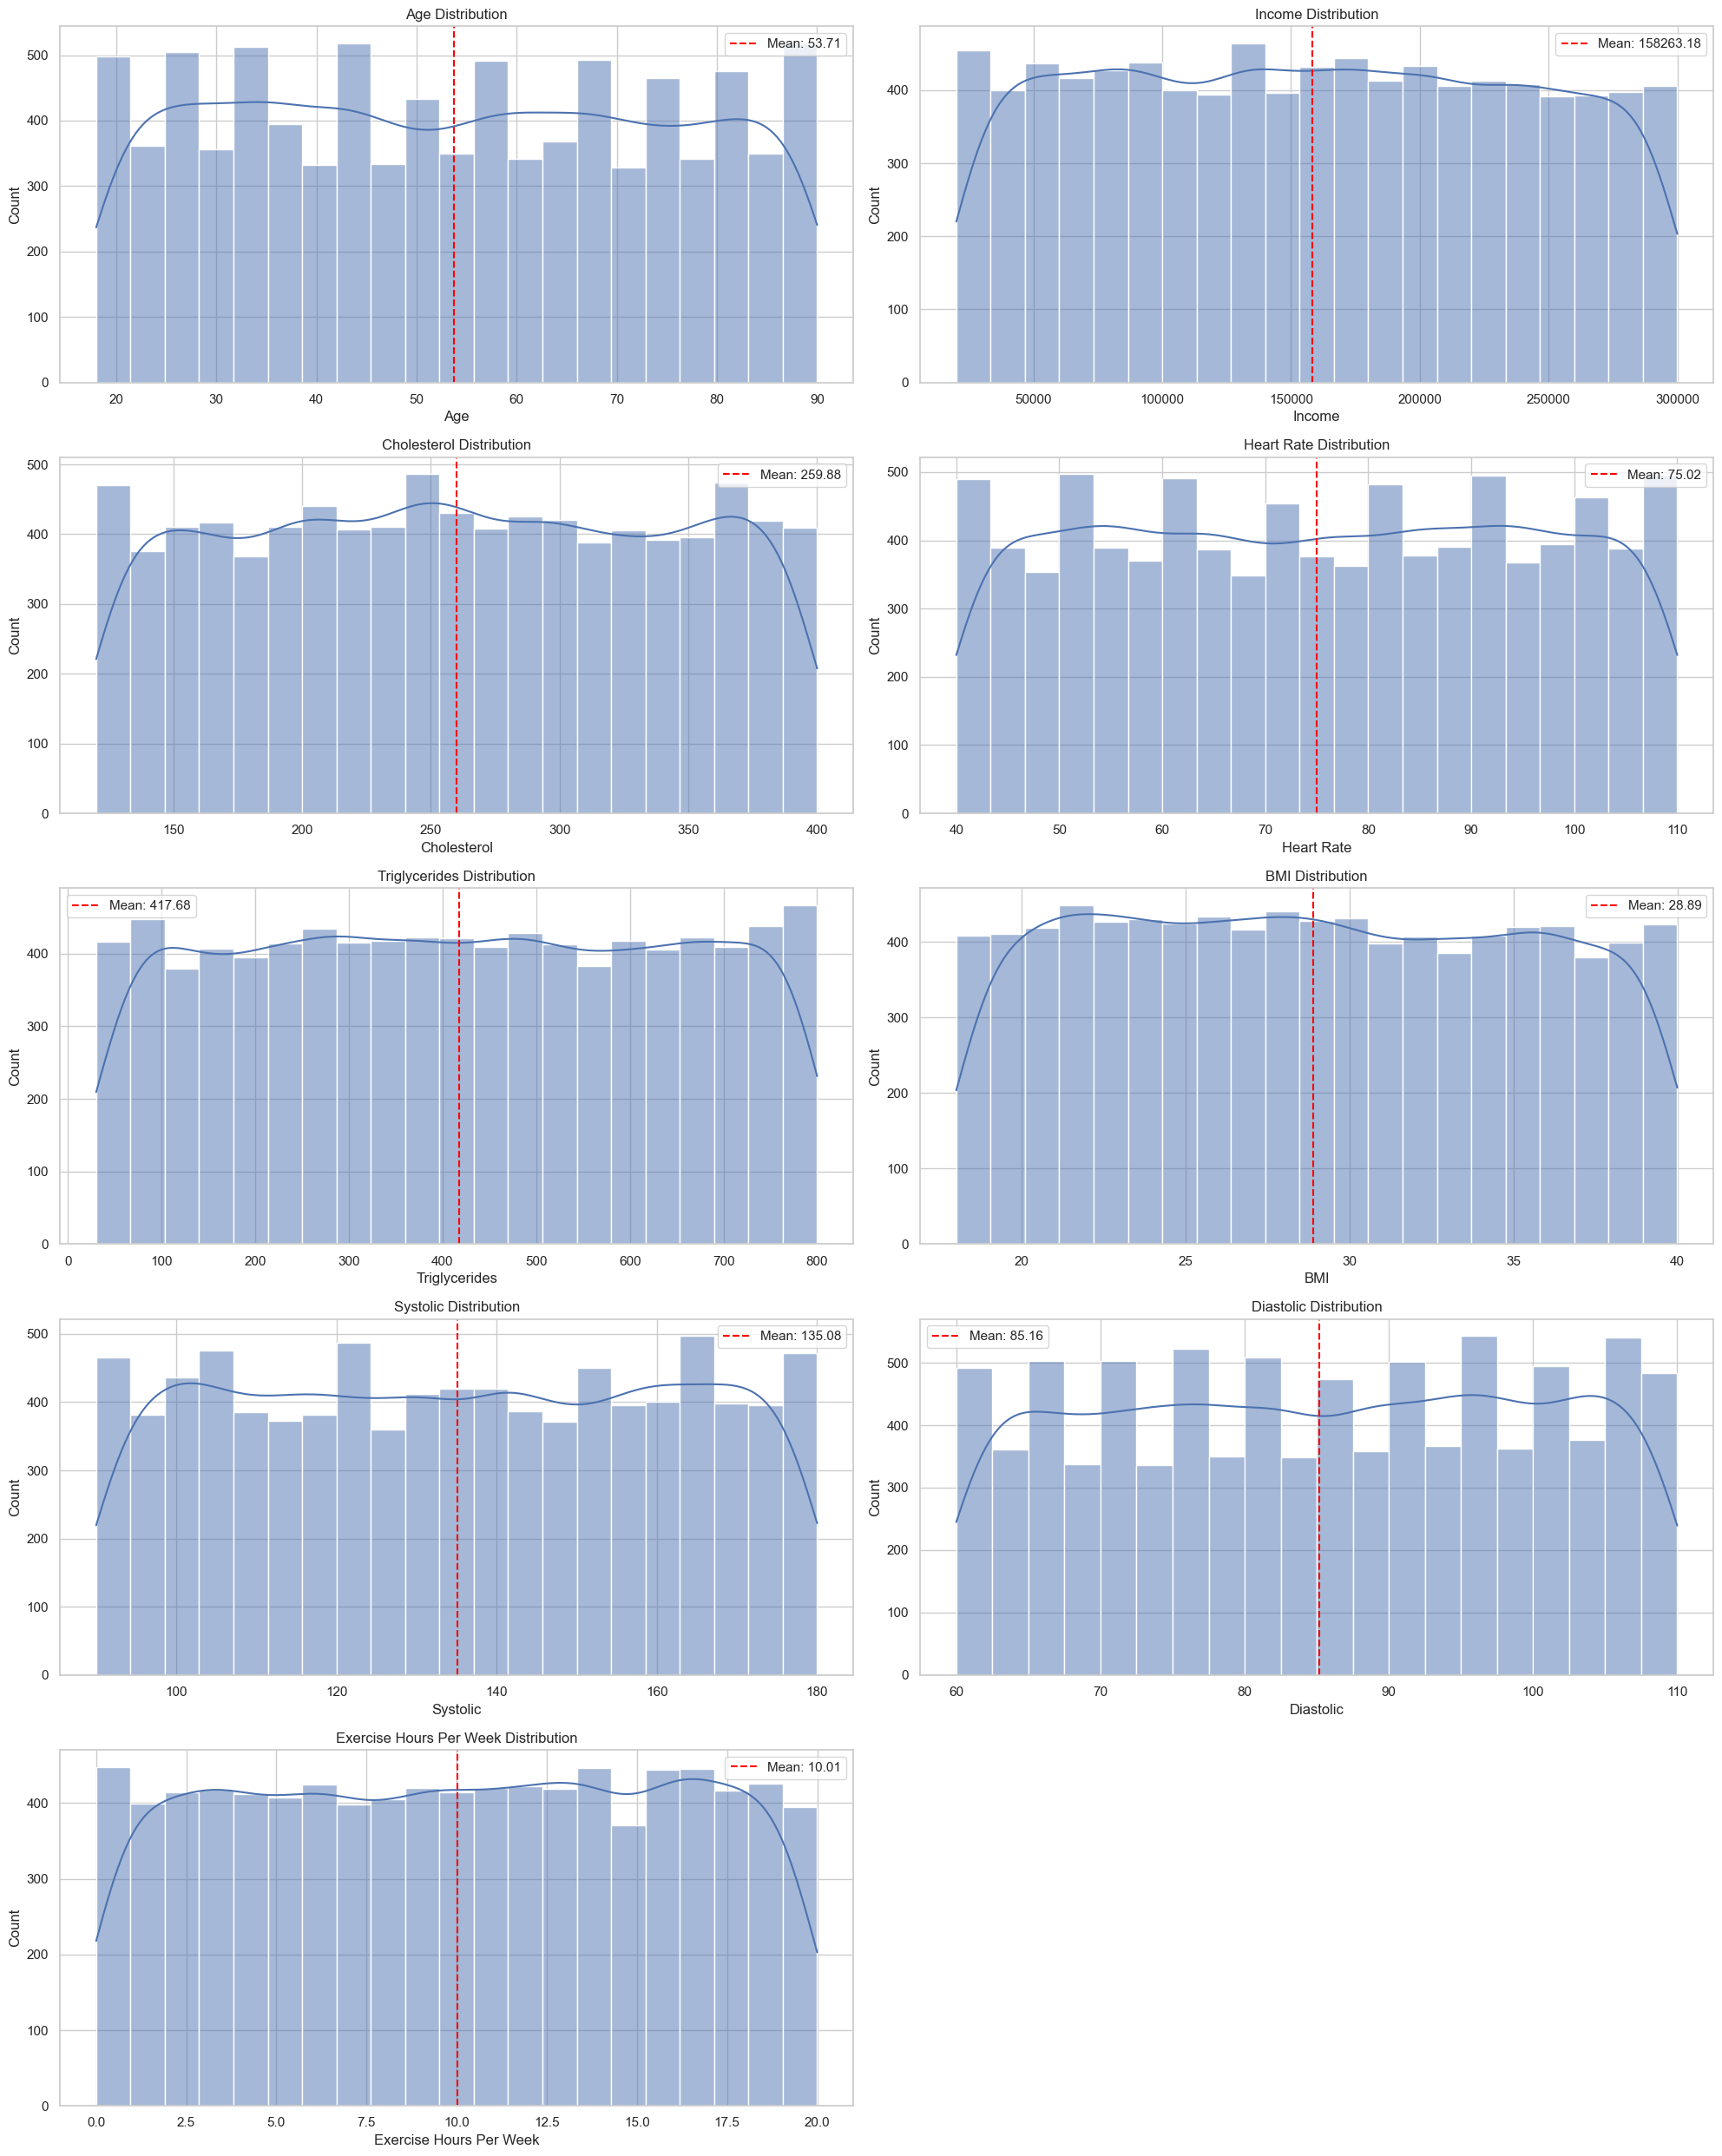

In [194]:
import math

cols = 2
rows = math.ceil(len(continuous_cols) / cols)

plt.figure(figsize=(20, rows * 5))

for i, col in enumerate(continuous_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(full_df[col], kde=True)

    mean = full_df[col].mean()
    plt.axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:.2f}")

    plt.title(f"{col} Distribution")
    plt.legend()

plt.tight_layout()
plt.show()


In [174]:
# Calculate Skewness for all continuous_cols columns
skewness = full_df[continuous_cols].skew().sort_values(ascending=False)

print("Skewness of Numerical Features")
print(skewness)

# Categorize based on Skewness
highly_skewed = skewness[abs(skewness) > 1].index.tolist()
moderately_skewed = skewness[(abs(skewness) > 0.5) & (abs(skewness) <= 1)].index.tolist()
normally_distributed = skewness[abs(skewness) <= 0.5].index.tolist()

print(f"\nHighly Skewed (> 1 or < -1): {highly_skewed}")
print(f"Moderately Skewed (0.5 to 1): {moderately_skewed}")
print(f"Approximately Normal (-0.5 to 0.5): {normally_distributed}")


Skewness of Numerical Features
BMI                        0.035996
Age                        0.028498
Income                     0.021792
Cholesterol               -0.000955
Triglycerides             -0.001915
Systolic                  -0.002661
Heart Rate                -0.003227
Exercise Hours Per Week   -0.016387
Diastolic                 -0.023375
dtype: float64

Highly Skewed (> 1 or < -1): []
Moderately Skewed (0.5 to 1): []
Approximately Normal (-0.5 to 0.5): ['BMI', 'Age', 'Income', 'Cholesterol', 'Triglycerides', 'Systolic', 'Heart Rate', 'Exercise Hours Per Week', 'Diastolic']


## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
#### Qn. What proportion of patients smoke?
- Ans: Proportion of smokers is 89.68%.


#### Qn. Which diet category is most common?
- Ans: Most common diet is Healthy.

#### Qn. Which countries are most represented?
- Ans: Top 5 Most Represented Countries:
Germany           477,
Argentina         471,
Brazil            462,
United Kingdom    457,
Australia         449.

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

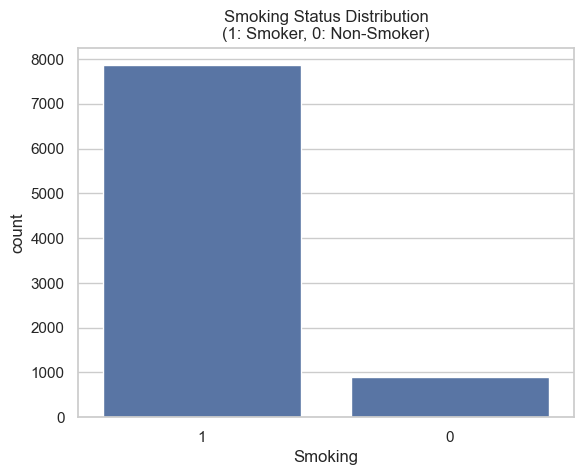

Proportion of smokers: 89.68%


In [177]:
# 1. Smoking Status (from lifestyle)
sns.countplot(data=lifestyle, x='Smoking', order=lifestyle['Smoking'].value_counts().index)

plt.title('Smoking Status Distribution\n(1: Smoker, 0: Non-Smoker)')
plt.show()

# Proportion of patients who smoke
smoking_proportion = full_df['Smoking'].mean()
print(f"Proportion of smokers: {smoking_proportion:.2%}")


# sns.countplot is specifically designed for categorical data. 
# It counts the number of occurrences for each category and displays them as bars.

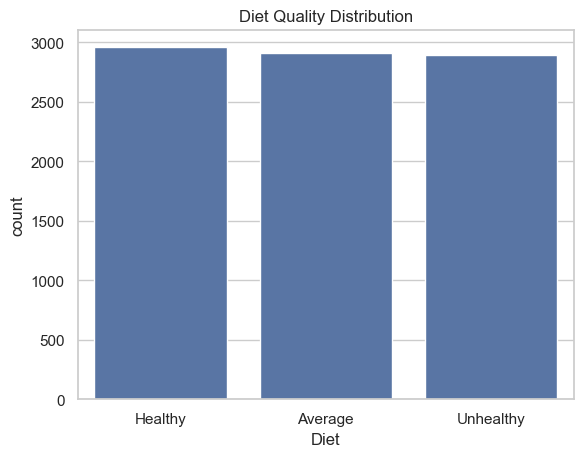

Most common diet: Healthy


In [178]:
# 2. Diet Quality (from lifestyle)
sns.countplot(data=lifestyle, x='Diet', order=lifestyle['Diet'].value_counts().index)

plt.title('Diet Quality Distribution')
plt.show()

# Most common diet category
most_common_diet = full_df['Diet'].value_counts().idxmax()
print(f"Most common diet: {most_common_diet}")

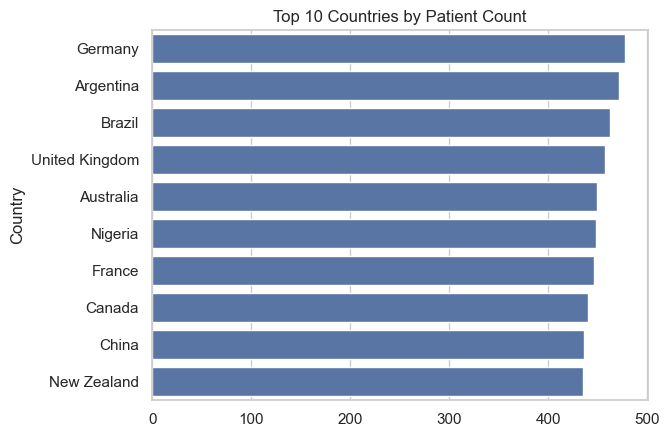


Top 5 Most Represented Countries:
Country
Germany           477
Argentina         471
Brazil            462
United Kingdom    457
Australia         449
Name: count, dtype: int64


In [179]:
# 3. Top 10 Countries (from demographics)
top_countries = demographics['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title('Top 10 Countries by Patient Count')
plt.show()

# Top 5 most represented countries
print("\nTop 5 Most Represented Countries:")
print(full_df['Country'].value_counts().head())

# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
#### Qn. Do smokers show noticeably higher risk counts?
- Ans: No. Surprisingly, the risk is slightly lower for smokers (49.6%) compared to non-smokers (50.4%). This suggests that in this specific dataset, smoking status is not a primary driver of heart attack risk.

#### Qn. Does diet quality appear protective against heart attack risk?
- Ans: No, the heart attack risk is often distributed very evenly across Healthy, Average, and Unhealthy diet categories in this sample.

#### Qn. Is there a difference in risk between male and female patients?
- Ans: No. The risk for females is roughly 49.8% compared to 50.2% for male. This indicates a nearly equal distribution of risk across genders, with less than a 0.5% difference.

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

In [61]:
# Merge demographics (Sex) and lifestyle (Smoking, Diet, Heart Attack Risk(Target)) for bivariate analysis
analysis_df = pd.merge(lifestyle, demographics[['Patient ID', 'Sex']], on='Patient ID')

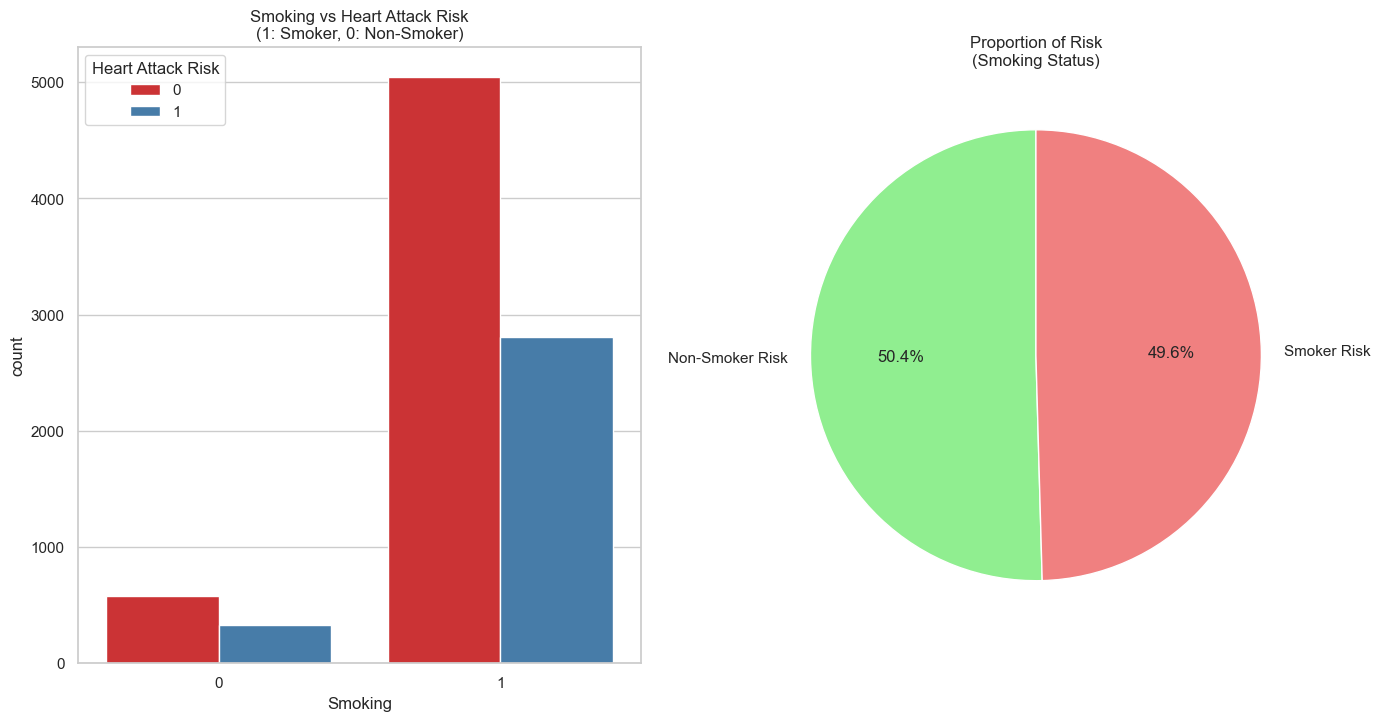

In [184]:
plt.figure(figsize=(16, 8))


# 1. Smoking Status vs Heart Attack Risk
plt.subplot(1, 2, 1)
sns.countplot(data=analysis_df, x='Smoking', hue='Heart Attack Risk', palette='Set1')
plt.title('Smoking vs Heart Attack Risk\n(1: Smoker, 0: Non-Smoker)')


plt.subplot(1, 2, 2)
smoking_risk = analysis_df.groupby('Smoking')['Heart Attack Risk'].mean()
plt.pie(smoking_risk, labels=['Non-Smoker Risk', 'Smoker Risk'], autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
plt.title('Proportion of Risk\n(Smoking Status)')

plt.show()

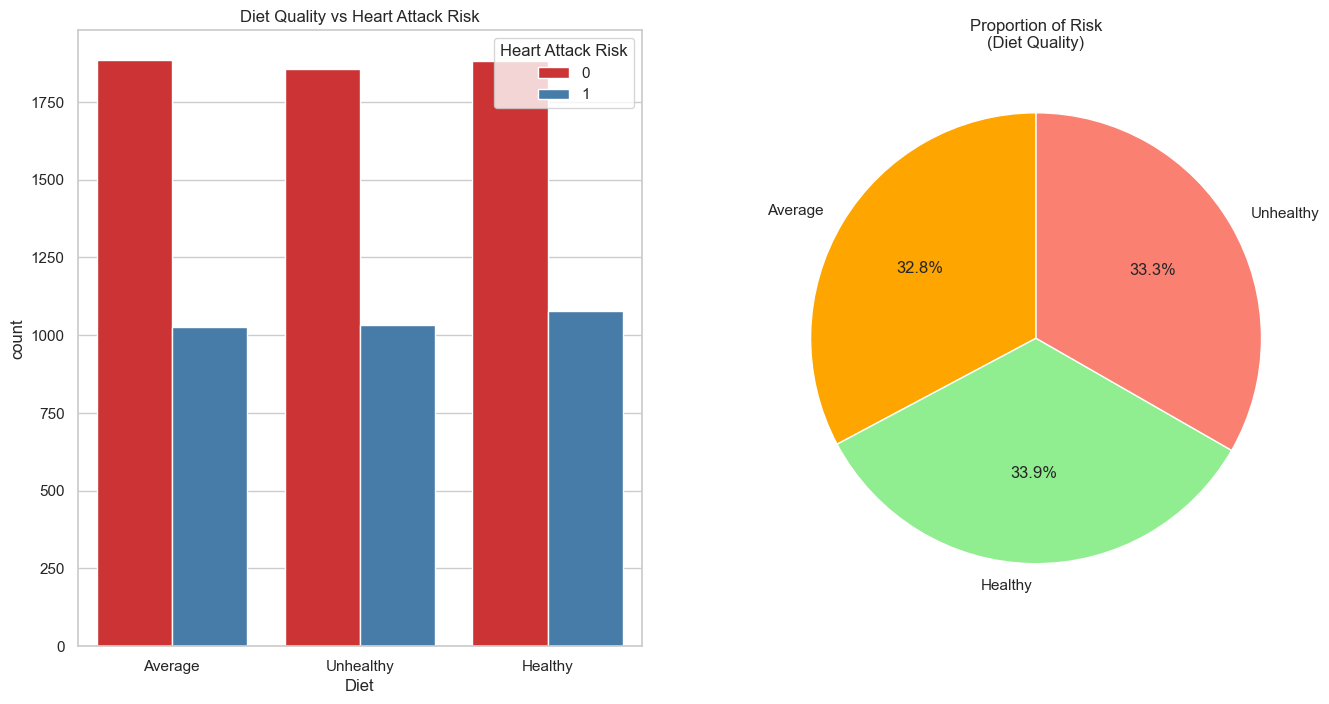

In [185]:
plt.figure(figsize=(16, 8))

# 2. Diet Quality vs Heart Attack Risk
plt.subplot(1, 2, 1)
sns.countplot(data=analysis_df, x='Diet', hue='Heart Attack Risk', palette='Set1')
plt.title('Diet Quality vs Heart Attack Risk')

plt.subplot(1, 2, 2)
diet_risk = analysis_df.groupby('Diet')['Heart Attack Risk'].mean()
plt.pie(diet_risk, labels=diet_risk.index, autopct='%1.1f%%', colors=['orange', 'lightgreen', 'salmon'], startangle=90)
plt.title('Proportion of Risk\n(Diet Quality)')

plt.show()

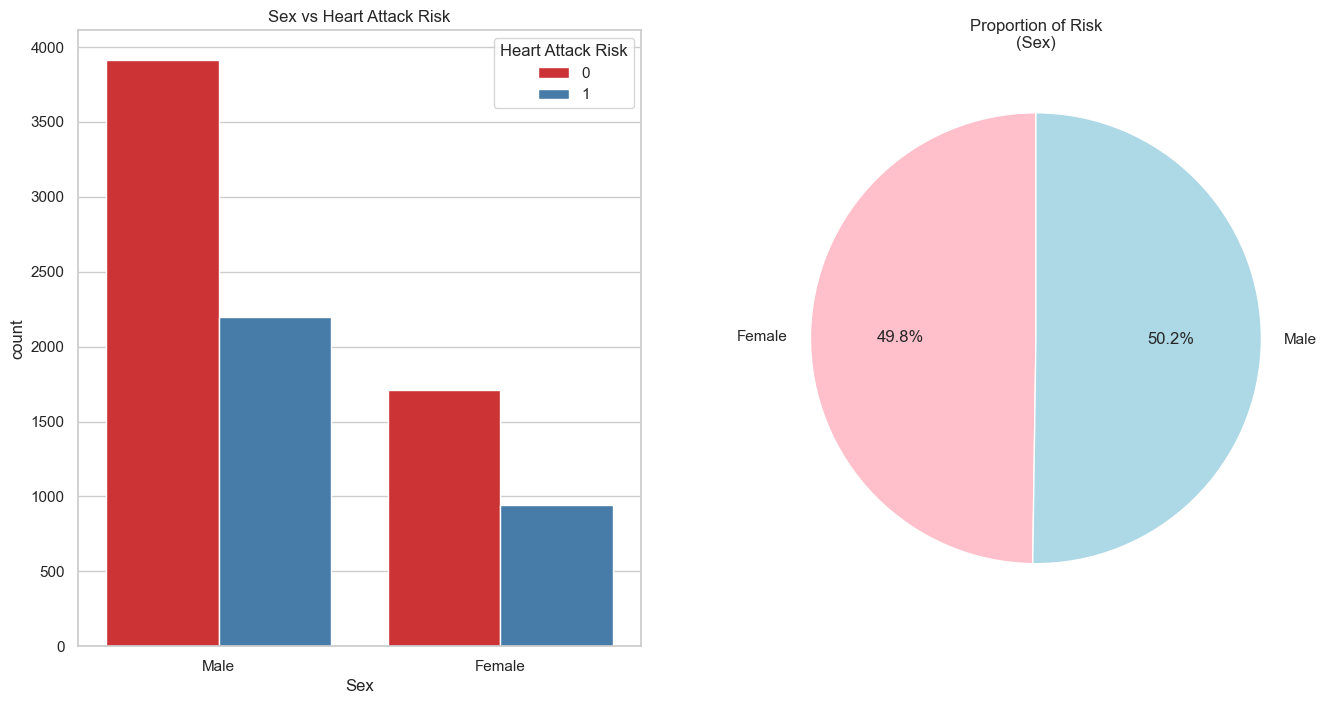

In [106]:
plt.figure(figsize=(16, 8))

# 3. Sex vs Heart Attack Risk
plt.subplot(1, 2, 1)
sns.countplot(data=analysis_df, x='Sex', hue='Heart Attack Risk', palette='Set1')
plt.title('Sex vs Heart Attack Risk')

plt.subplot(1, 2, 2)
sex_risk = analysis_df.groupby('Sex')['Heart Attack Risk'].mean()
plt.pie(sex_risk, labels=sex_risk.index, autopct='%1.1f%%', colors=['pink', 'lightblue'], startangle=90)
plt.title('Proportion of Risk\n(Sex)')

plt.show()

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:

#### Qn. Which feature has the highest correlation with Heart Attack Risk?

- Ans: There is no single dominant numerical feature in this dataset that correlates strongly with Heart Attack Risk. I observed only very weak positive correlations (~0.02) with features like Cholesterol, Diabetes, and Systolic BP. This indicates that risk is multi-factorial and cannot be predicted by a single linear factor, which is why a simple "straight-line" (Pearson) relationship is not visible.

#### Qn. Are any features highly correlated with each other (multicollinearity)?

- Ans: Most features are independent of one another. However, Age and Smoking Status show a moderate positive correlation of 0.39, which is the strongest relationship found in the numerical data. This suggests a demographic trend where smoking habits may vary with the age of the patients.

#### Qn. Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

- Ans: Surprisingly, in this dataset, Systolic and Diastolic BP show a very weak correlation (0.01). In a typical clinical setting, we would expect a strong positive correlation (0.7+) since both measure the pressure in the same circulatory system at different stages of a heartbeat. This weak result might suggest that these two variables are acting as independent risk factors in this particular population, or it may be a characteristic of the underlying data distribution.

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

In [107]:
# 1. Merge all three datasets into one 'full_df'
full_df = pd.merge(demographics, clinical, on='Patient ID')
full_df = pd.merge(full_df, lifestyle, on='Patient ID')

In [110]:
# 2. Extract only numeric columns for correlation
numeric_df = full_df.select_dtypes(include=[np.number])

In [111]:
# 3. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

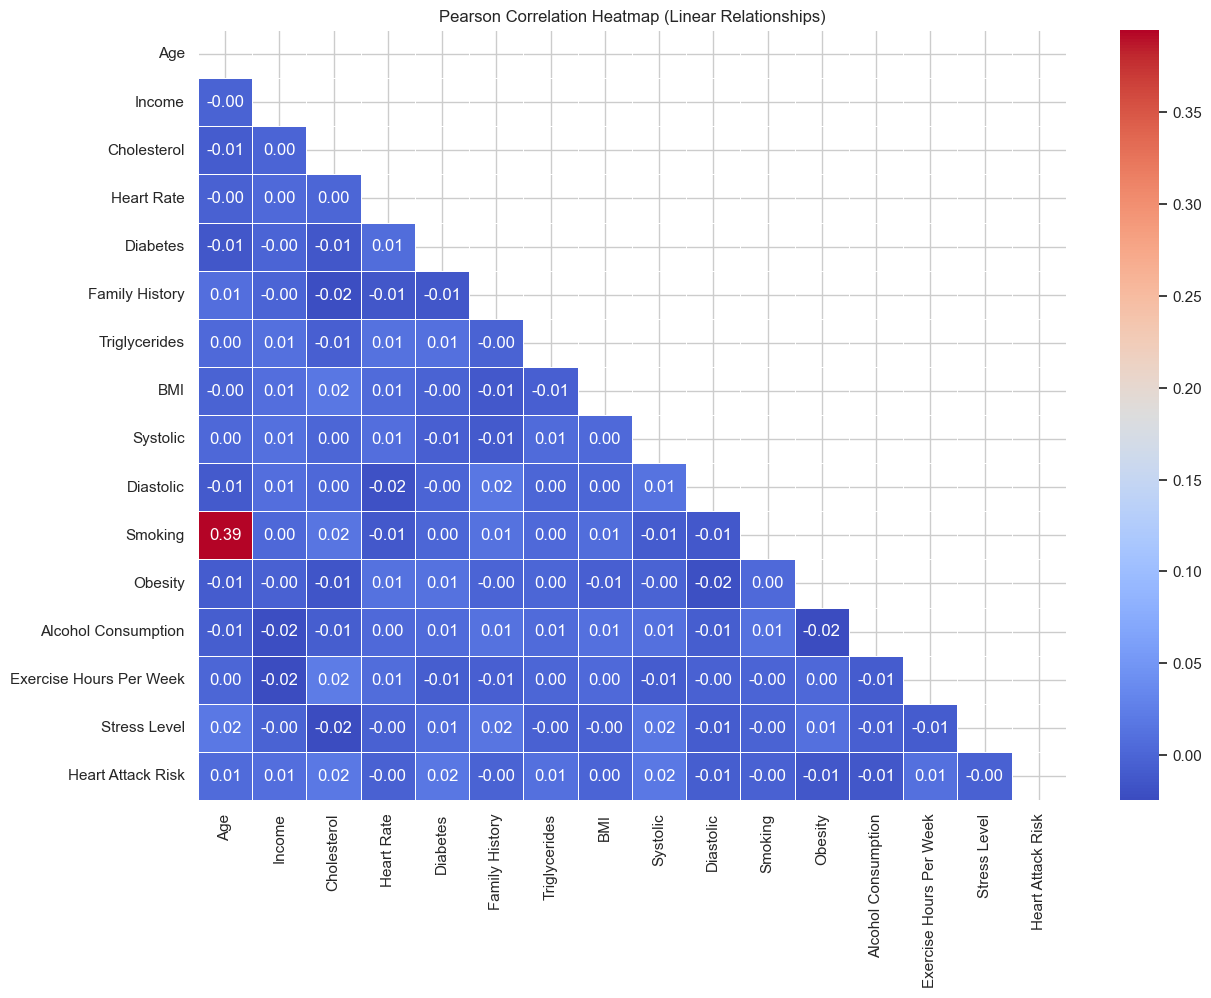

In [ ]:
# 4. Plot the Correlation Heatmap
plt.figure(figsize=(14, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Optional: It hides the upper triangle for clarity
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Pearson Correlation Heatmap (Linear Relationships)')
plt.show()

In [138]:
# Check specific Pearson correlations with the Target variable
print("--- Pearson Correlation with Heart Attack Risk ---")
print(corr_matrix['Heart Attack Risk'].sort_values(ascending=False))

--- Pearson Correlation with Heart Attack Risk ---
Heart Attack Risk          1.000000
Cholesterol                0.019340
Systolic                   0.018585
Diabetes                   0.017225
Exercise Hours Per Week    0.011133
Triglycerides              0.010471
Income                     0.009628
Age                        0.006403
BMI                        0.000020
Family History            -0.001652
Smoking                   -0.004051
Stress Level              -0.004111
Heart Rate                -0.004251
Diastolic                 -0.007509
Obesity                   -0.013318
Alcohol Consumption       -0.013778
Name: Heart Attack Risk, dtype: float64


# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
#### Qn. Are the Spearman results significantly different from Pearson? 

- Ans: No, the Spearman results are not significantly different from the Pearson results. For example, Cholesterol decrease slightly to 0.019271 (from ~0.019340 in Pearson). These are still extremely weak correlations. The overall hierarchy and magnitude of the relationships is the same.


#### QN. If they differ, what might that suggest about the data's linearity or outliers? 

- Ans: Since the two results are very similar and are both extremely low, it suggests two things:

- Linearity: There is no "hidden" non-linear monotonic relationship between these individual features and Heart Attack Risk. Even when we account for non-linearity using ranks (Spearman), the connection remains weak.

- Outliers: The presence of outlier is not drastically distorting the Pearson correlation. If outliers were the main problem, the Spearman values would typically be much higher than the Pearson ones.

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

In [ ]:
# Calculate the Pearson correlation matrix
pearson_corr = numeric_df.corr()

# Calculate the Spearman correlation matrix (method='spearman')
spearman_corr = numeric_df.corr(method='spearman')

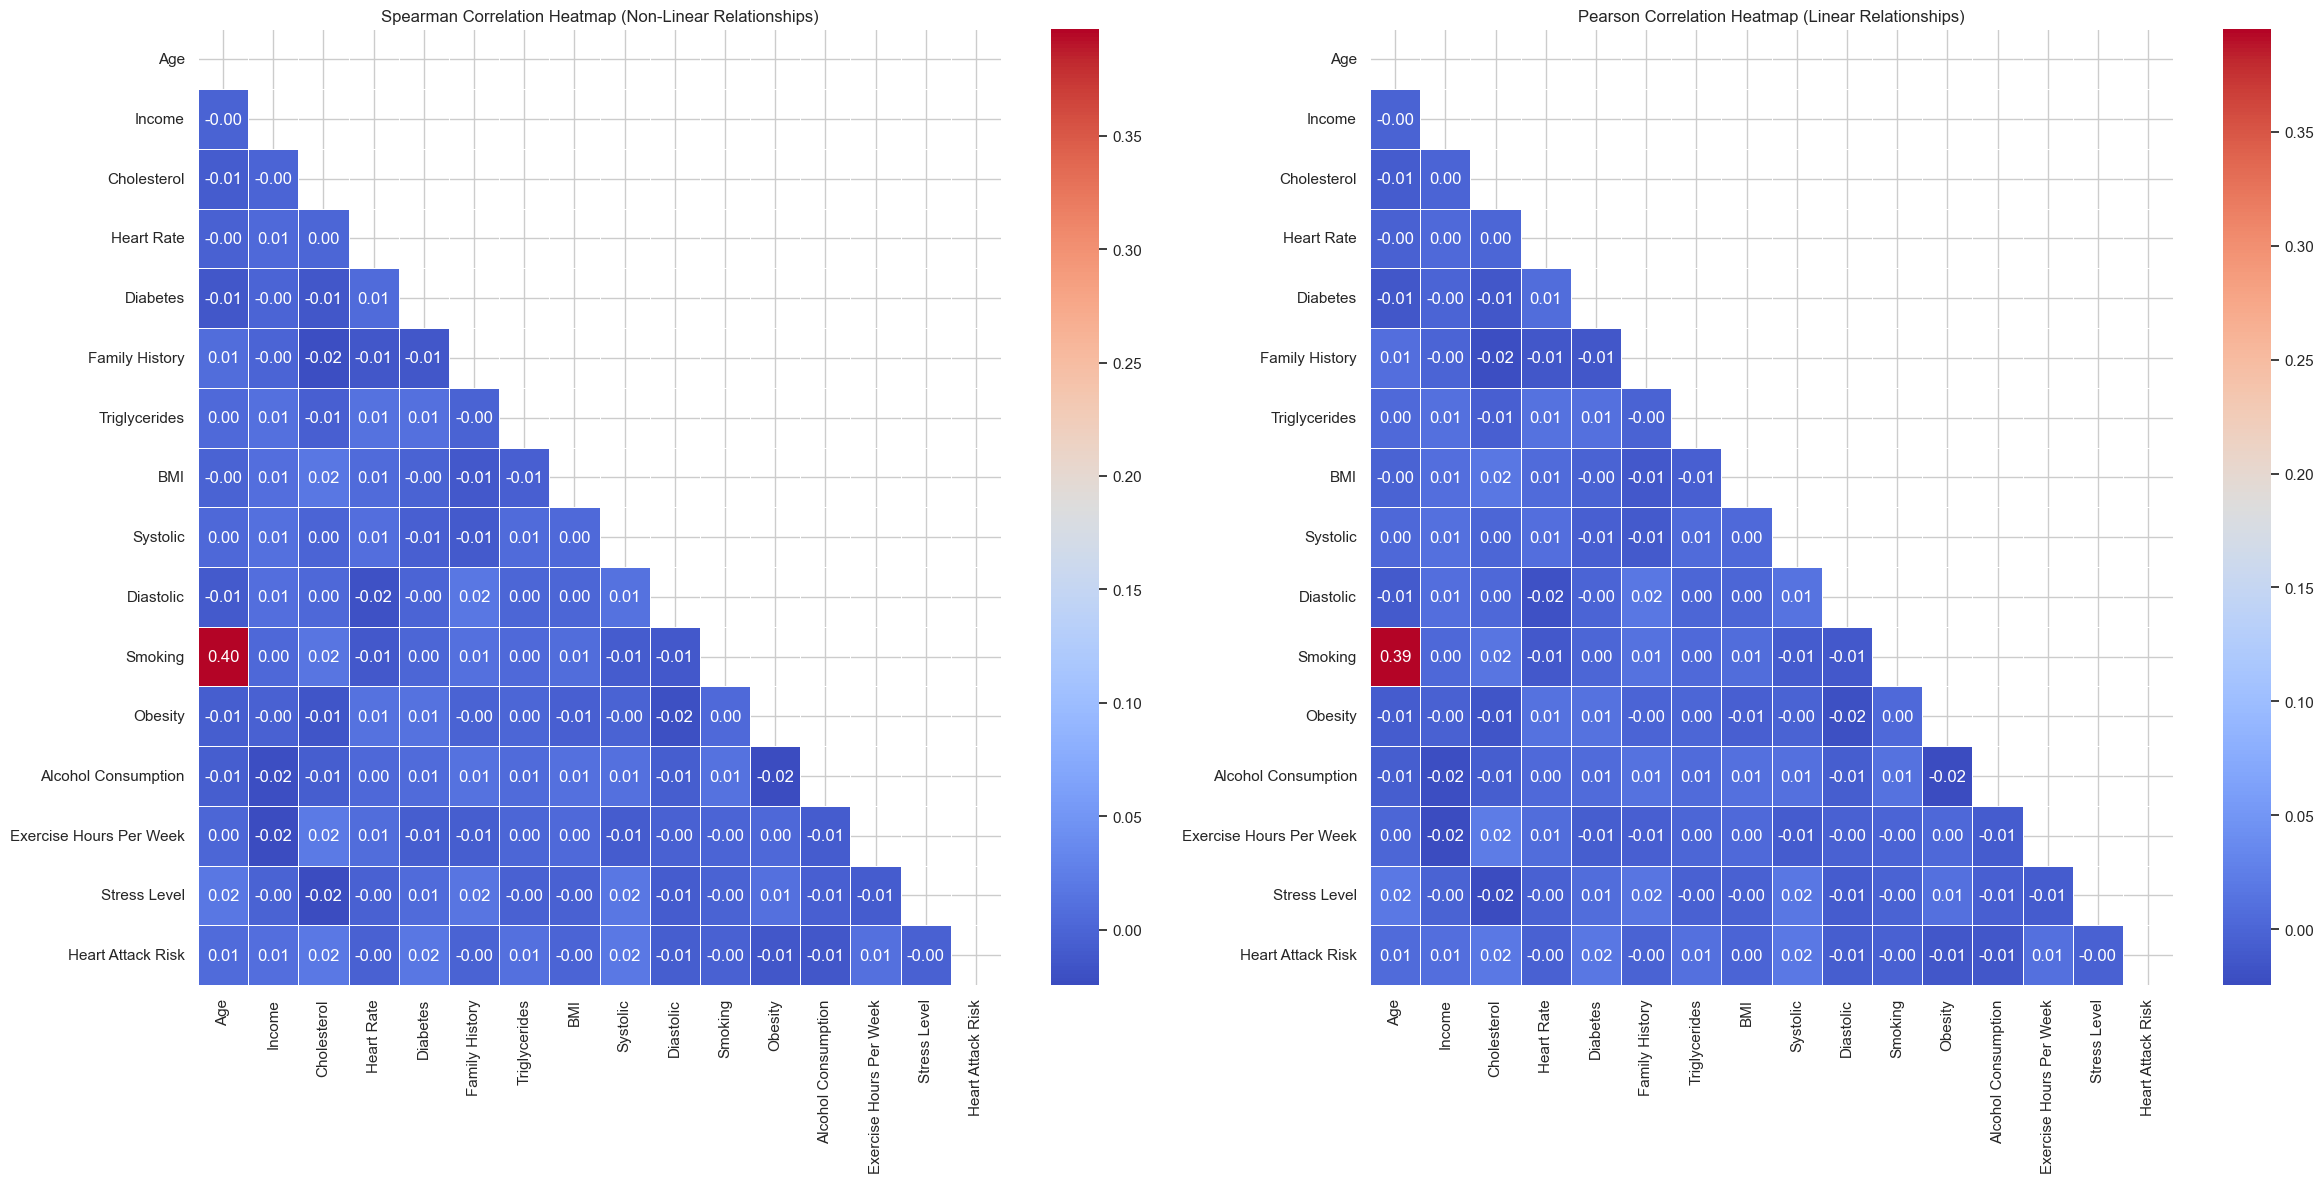

In [ ]:
plt.figure(figsize=(24, 12))

# Plot the Spearman Heatmap
plt.subplot(1,2,1)
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Spearman Correlation Heatmap (Non-Linear Relationships)')

# Plot the Pearson Heatmap
plt.subplot(1,2,2)
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Heatmap (Linear Relationships)')

plt.tight_layout()
plt.show()

In [136]:

# Check specific Spearman correlations with the Target variable
print("--- Spearman Correlation with Heart Attack Risk ---")
print(spearman_corr['Heart Attack Risk'].sort_values(ascending=False))

--- Spearman Correlation with Heart Attack Risk ---
Heart Attack Risk          1.000000
Cholesterol                0.019271
Systolic                   0.018642
Diabetes                   0.017225
Exercise Hours Per Week    0.011166
Triglycerides              0.010452
Income                     0.009586
Age                        0.006429
BMI                       -0.000120
Family History            -0.001652
Smoking                   -0.004051
Stress Level              -0.004115
Heart Rate                -0.004404
Diastolic                 -0.007701
Obesity                   -0.013318
Alcohol Consumption       -0.013778
Name: Heart Attack Risk, dtype: float64


## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


In [143]:
# 1. Count patients in each class
print(full_df['Heart Attack Risk'].value_counts())

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64


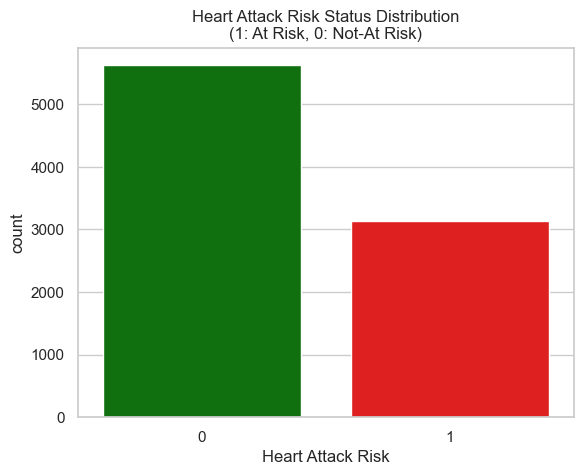

In [157]:
# 2. Visualize class distribution
sns.countplot(data=full_df, x='Heart Attack Risk', 
              order=full_df['Heart Attack Risk'].value_counts().index, 
              hue='Heart Attack Risk', 
              palette={0: 'green', 1: 'red'}, 
              legend=False)

plt.title('Heart Attack Risk Status Distribution\n(1: At Risk, 0: Not-At Risk)')
plt.show()

# Final Reflection

## Answer the following:

### 1. Missing Values
#### Qn. How did you handle missing values in each dataset?

- Ans: We found 0 missing values in all clinical, demographic, and lifestyle features after running .isnull().sum().

#### Qn. Why did you choose that approach (drop, fill, or mixed strategy)?

- Ans: Since there were no missing values, no action (like dropping or filling) was required.

---

### 2. Data Quality Issues
#### Qn. Did you find any unrealistic or inconsistent values?
- Ans: No unrealistic values were found, but the data structure was inconsistent. Specifically, the Blood Pressure column was stored as a combined string (e.g., "158/88") which prevented numerical analysis.

#### Qn. How did you identify them?
- Ans: I identified these using df.info() and df.head(), which revealed that Blood Pressure was an object (string) type instead of a numeric type.

#### Qn. What action did you take (remove, clip, correct, or keep)?
- Ans: I corrected the issue by using .str.split('/') to create two new numeric columns: Systolic and Diastolic. Regarding outliers, I checked all numerical columns using the IQR method and confirmed there were 0 outliers, so no clipping or removal was necessary.

---

### 3. Insights from EDA
#### Qn. What patterns did you observe in the data?
- Ans: The most notable pattern was a moderate positive correlation (0.39 Person and 0.4 Spearman) between Age and Smoking. Most other lifestyle and clinical features appeared to be independent of one another.

#### Qn. Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Ans: No. Correlations with Heart Attack Risk were consistently very low (~0.02). For example, Cholesterol and Systolic BP showed only a tiny positive relationship with risk.

#### Qn. Were there any surprising findings or trends?
- Ans: Yes. It was surprising to find that Smokers (49.6%) actually had a slightly lower risk count than Non-Smokers (50.4%) in this dataset. The risk is distributed almost perfectly 50/50 across almost all categories like diet and sex.

---

### 4. Correlation Findings
#### Qn. Were Pearson and Spearman results similar or different? What does that suggest?
- Ans: Both results were nearly identical and stayed very close to zero (ranging from -0.02 to +0.02). This suggests that there is no strong linear connection (where one value goes up and risk follows in a straight line) and no strong ranked connection (where higher values always lead to higher risk). In short, it tells us that heart attack risk in this dataset is not driven by any single clinical feature alone; it’s likely a complex result of many factors interacting at the same time.

#### Qn. Did you find any multicollinearity (two features highly correlated with each other)?
- Ans: No. The highest correlation was 0.39 (Age vs Smoking), which is well within the safe range (below 0.7) for avoiding multicollinearity issues in machine learning.

---

### 5. Improvements
#### Qn. If you had more time, what would you improve in your data cleaning process?
- Ans: I would perform a Health Guideline Audit to ensure all clinical values (like Cholesterol and Blood Pressure) fall within medically realistic ranges for humans. Then, I would use advanced tools like Lasso Regression or PCA (Principal Component Analysis) to automatically identify and remove unnecessary columns that don't help in predicting risk. I would also segment the data to look at specific groups (like only high-income or only elderly patients) to see if their health patterns differ from the average.

#### Qn. Would you try different strategies for missing values or outliers?
- Ans: Since this dataset was already clean, I would focus on Data Scaling and Normalization. This ensures that columns with large numbers (like Income) don't overpower columns with small numbers (like BMI) during analysis. This is a great alternative strategy to just looking for missing data or outliers.

#### Qn. What additional checks or visualizations would you add?
- Ans: I would definitely add Pairplots. These allow us to visualize relationships between multiple features at once in a grid, showing how things like Age, Cholesterol, and Risk all interact together in a single view.

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  